# Fine-tuning y comparación de ConvNeXt Tiny y ViT Base para la clasificación de enfermedades en hojas (PlantVillage)

### Entregable N°3 — Demo y Presentación Final

**Equipo 07 — 1INF52 Deep Learning (2026-1)**

- 20220540 Regalado Reyes, Renzo Joaquin
- 20220231 Velásquez Paredes, Ramón Antonio
- 20221953 Olivares Cornejo, Marcelo Daniel
- 20192506 Guzman Vega, Shanti Jeremy

---

### Descripción

Se realiza *fine-tuning* de dos arquitecturas de visión preentrenadas, **ConvNeXt Tiny** y **ViT Base**, sobre el dataset PlantVillage (38 clases de cultivo–enfermedad), y se comparan sus resultados.

Para verificar la solidez de las métricas, cada arquitectura se evalúa bajo dos esquemas de partición:

1. **Split oficial de PlantVillage**, que ya está construido a nivel de hoja física para evitar fuga de información entre train y test.
2. **Split agrupado por `leaf_id`** construido en este trabajo, que vuelve a garantizar que ninguna hoja se reparta entre conjuntos.

La comparación entre ambos esquemas permite comprobar si el alto rendimiento se debe a fuga de información o a otras causas.

### Instalación de librerías

Se instalan en una sola celda las dependencias de Hugging Face (`transformers`, `datasets`, `evaluate`, `accelerate`) y `scikit-learn` para métricas y particiones.

In [3]:
!pip install -q transformers datasets evaluate accelerate huggingface_hub fsspec scikit-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


### Importaciones, semilla y entorno

Se fija una semilla global (`SEED = 42`) para reproducibilidad y se reporta el dispositivo de cómputo disponible.

In [6]:
# Importaciones principales del proyecto.

import os
import gc
import time
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from collections import defaultdict
from huggingface_hub import hf_hub_download
from datasets import Dataset, DatasetDict, Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import evaluate

from torchvision.transforms import (
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomRotation,
    ColorJitter,
    RandomResizedCrop,
    Resize,
    CenterCrop,
    ToTensor,
)

from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    TrainingArguments,
    Trainer,
    set_seed,
)

# Fijamos semilla para que los resultados sean reproducibles.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

set_seed(SEED)

# Mostramos información del entorno de ejecución.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo disponible: {device}")

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("Versión de CUDA en PyTorch:", torch.version.cuda)
    print("Capacidad de cómputo:", torch.cuda.get_device_capability(0))

print("Versión de PyTorch:", torch.__version__)

Dispositivo disponible: cuda
GPU: NVIDIA GeForce RTX 5090
Versión de CUDA en PyTorch: 12.8
Capacidad de cómputo: (12, 0)
Versión de PyTorch: 2.12.0.dev20260408+cu128


### Descarga y construcción del dataset

Se descarga PlantVillage (configuración *color*) y se construye un `DatasetDict` con los splits oficiales (43 596 imágenes de train, 10 709 de test). Para cada imagen se derivan los campos `crop`, `disease` y `leaf_id`.

In [7]:
# Descargamos el dataset PlantVillage desde Hugging Face.
repo_id_data = "mohanty/PlantVillage"

data_zip = hf_hub_download(repo_id=repo_id_data, repo_type="dataset", filename="data.zip")
train_txt = hf_hub_download(repo_id=repo_id_data, repo_type="dataset", filename="splits/color_train.txt")
test_txt  = hf_hub_download(repo_id=repo_id_data, repo_type="dataset", filename="splits/color_test.txt")

# Carpeta de extracción. En Colab usa /content; en local puedes cambiarla.
extract_dir = os.environ.get("PV_DIR", "/content/plantvillage_data")
raw_dir = os.path.join(extract_dir, "raw")
os.makedirs(extract_dir, exist_ok=True)

if not os.path.exists(raw_dir):
    with zipfile.ZipFile(data_zip, "r") as zf:
        zf.extractall(extract_dir)

print("Datos extraídos en:", extract_dir)
print("¿Existe la carpeta raw?:", os.path.exists(raw_dir))


def build_split(txt_path, root_dir):
    """Construye un split a partir de un .txt oficial de PlantVillage."""
    with open(txt_path, "r", encoding="utf-8") as f:
        rel_paths = [line.strip() for line in f if line.strip()]

    abs_paths = [os.path.join(root_dir, p) for p in rel_paths]

    # La etiqueta de clase se obtiene del nombre de la carpeta.
    labels_texto = [p.split("/")[2] for p in rel_paths]

    # Atributos adicionales útiles para análisis posteriores.
    crops = [lbl.split("___")[0] for lbl in labels_texto]
    diseases = [lbl.split("___", 1)[1] for lbl in labels_texto]

    # leaf_id: identificador de la hoja física. En PlantVillage el nombre de archivo
    # suele compartir un prefijo para fotos de la MISMA hoja tomadas en distinto ángulo.
    # Lo usaremos para evitar fuga de información entre train y test.
    leaf_ids = [os.path.basename(p).split("___")[0] for p in rel_paths]

    ds = Dataset.from_dict({
        "image": abs_paths,
        "label": labels_texto,
        "crop": crops,
        "disease": diseases,
        "leaf_id": leaf_ids,
    })
    return ds.cast_column("image", Image())


dataset_original = DatasetDict({
    "train": build_split(train_txt, extract_dir),
    "test":  build_split(test_txt, extract_dir),
})

print(dataset_original)
print("Ejemplo de etiqueta:", dataset_original["train"][0]["label"])

Datos extraídos en: /content/plantvillage_data
¿Existe la carpeta raw?: True
DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'crop', 'disease', 'leaf_id'],
        num_rows: 43596
    })
    test: Dataset({
        features: ['image', 'label', 'crop', 'disease', 'leaf_id'],
        num_rows: 10709
    })
})
Ejemplo de etiqueta: Raspberry___healthy


### Codificación de etiquetas

Se construye el mapeo `label2id` / `id2label` sobre las 38 clases presentes en train y test, garantizando consistencia entre todos los experimentos.

In [8]:
# Usamos todas las etiquetas vistas (train + test) para no perder ninguna clase.
all_labels = list(dataset_original["train"]["label"]) + list(dataset_original["test"]["label"])
labels_ordenadas = sorted(set(all_labels))

label2id = {label: idx for idx, label in enumerate(labels_ordenadas)}
id2label = {idx: label for label, idx in label2id.items()}
NUM_CLASSES = len(labels_ordenadas)

print("Número de clases:", NUM_CLASSES)
print("Primera clase:", labels_ordenadas[0])


def encode_labels(example):
    example["labels"] = label2id[example["label"]]
    return example

dataset_original = dataset_original.map(encode_labels)

Número de clases: 38
Primera clase: Apple___Apple_scab


Map:   0%|          | 0/43596 [00:00<?, ? examples/s]

Map:   0%|          | 0/10709 [00:00<?, ? examples/s]

### Esquemas de partición

Se definen dos funciones de partición. `make_random_split` divide el train oficial en train/validation de forma estratificada y conserva el test oficial intacto. `make_leaf_split` reconstruye train/validation/test agrupando por `leaf_id`, de modo que todas las imágenes asociadas a un mismo identificador de hoja permanezcan en un solo conjunto. La función `check_leaf_overlap` verifica que no exista solapamiento de hojas entre conjuntos.

In [9]:
# --- Esquema 1: split aleatorio estratificado (reproduce el comportamiento original) ---
def make_random_split(val_size=0.10):
    """Devuelve un DatasetDict con train/validation/test usando split ALEATORIO."""
    base_train = dataset_original["train"]
    indices = np.arange(len(base_train))
    train_idx, val_idx = train_test_split(
        indices,
        test_size=val_size,
        random_state=SEED,
        stratify=base_train["labels"],
    )
    return DatasetDict({
        "train": base_train.select(train_idx.tolist()),
        "validation": base_train.select(val_idx.tolist()),
        "test": dataset_original["test"],  # test oficial intacto
    })


# --- Esquema 2: split agrupado por leaf_id (sin fuga de hoja) ---
def make_leaf_split(val_size=0.10, test_size=0.15):
    """Reconstruye train/validation/test garantizando que ninguna hoja (leaf_id) se
    reparta entre conjuntos. Parte del pool completo (train+test oficiales)."""
    pool = concatenate_pool()

    # Agrupamos índices por leaf_id.
    leaf_to_indices = defaultdict(list)
    leaf_to_label = {}
    for i, (lid, lab) in enumerate(zip(pool["leaf_id"], pool["labels"])):
        leaf_to_indices[lid].append(i)
        leaf_to_label[lid] = lab  # una hoja pertenece a una sola clase

    leaf_ids = list(leaf_to_indices.keys())
    leaf_labels = [leaf_to_label[l] for l in leaf_ids]

    # Split por HOJA, estratificado por clase a nivel de hoja.
    train_leaves, test_leaves = train_test_split(
        leaf_ids, test_size=test_size, random_state=SEED,
        stratify=_safe_stratify(leaf_labels),
    )
    train_leaf_labels = [leaf_to_label[l] for l in train_leaves]
    train_leaves, val_leaves = train_test_split(
        train_leaves, test_size=val_size, random_state=SEED,
        stratify=_safe_stratify(train_leaf_labels),
    )

    def gather(leaves):
        idxs = []
        for l in leaves:
            idxs.extend(leaf_to_indices[l])
        return sorted(idxs)

    return DatasetDict({
        "train": pool.select(gather(train_leaves)),
        "validation": pool.select(gather(val_leaves)),
        "test": pool.select(gather(test_leaves)),
    })


def concatenate_pool():
    """Une train+test oficiales en un solo Dataset (para el split por hoja)."""
    from datasets import concatenate_datasets
    return concatenate_datasets([dataset_original["train"], dataset_original["test"]])


def _safe_stratify(labels):
    """Devuelve labels para estratificar, o None si alguna clase tiene <2 hojas."""
    vals, counts = np.unique(labels, return_counts=True)
    return labels if counts.min() >= 2 else None


# Verificación: ¿el split por hoja realmente elimina la fuga?
def check_leaf_overlap(dd):
    tr = set(dd["train"]["leaf_id"])
    va = set(dd["validation"]["leaf_id"])
    te = set(dd["test"]["leaf_id"])
    print(f"  Hojas compartidas train∩test: {len(tr & te)}")
    print(f"  Hojas compartidas train∩val:  {len(tr & va)}")
    print(f"  Tamaños -> train:{len(dd['train'])} val:{len(dd['validation'])} test:{len(dd['test'])}")

print("Esquemas de split definidos: make_random_split() y make_leaf_split()")

Esquemas de split definidos: make_random_split() y make_leaf_split()


### Procesador de imágenes y transformaciones

Las transformaciones se generan a partir del `image_processor` de cada checkpoint, usando su resolución y normalización propias. El conjunto de entrenamiento aplica aumentos (recorte aleatorio, volteo, rotación y *color jitter*); validación y test usan solo redimensionado y recorte central.

In [10]:
def build_transforms(image_processor):
    """Crea transforms de train (con aumentos) y eval (sin aleatoriedad) para un checkpoint."""
    if "shortest_edge" in image_processor.size:
        img_size = image_processor.size["shortest_edge"]
    else:
        img_size = image_processor.size["height"]

    normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)

    train_transforms = Compose([
        RandomResizedCrop((img_size, img_size)),
        RandomHorizontalFlip(p=0.5),
        RandomRotation(degrees=10),
        ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        ToTensor(),
        normalize,
    ])
    eval_transforms = Compose([
        Resize((img_size, img_size)),
        CenterCrop((img_size, img_size)),
        ToTensor(),
        normalize,
    ])
    return train_transforms, eval_transforms, img_size


def attach_transforms(dataset_dict, train_tf, eval_tf):
    """Aplica las transforms a cada split (lazy, con with_transform)."""
    def preprocess_train(batch):
        return {
            "pixel_values": [train_tf(img.convert("RGB")) for img in batch["image"]],
            "labels": batch["labels"],
        }
    def preprocess_eval(batch):
        return {
            "pixel_values": [eval_tf(img.convert("RGB")) for img in batch["image"]],
            "labels": batch["labels"],
        }
    return (
        dataset_dict["train"].with_transform(preprocess_train),
        dataset_dict["validation"].with_transform(preprocess_eval),
        dataset_dict["test"].with_transform(preprocess_eval),
    )

### Métricas y función de *collate*

Se emplean *accuracy* y **macro-F1**. La macro-F1 promedia el F1 de cada clase con igual peso, lo que la hace adecuada frente al desbalance de clases del dataset.

In [11]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels_reales = eval_pred
    predicciones = np.argmax(logits, axis=1)
    accuracy = accuracy_metric.compute(predictions=predicciones, references=labels_reales)["accuracy"]
    macro_f1 = f1_metric.compute(predictions=predicciones, references=labels_reales, average="macro")["f1"]
    return {"accuracy": accuracy, "macro_f1": macro_f1}

def collate_fn(batch):
    pixel_values = torch.stack([example["pixel_values"] for example in batch])
    labels = torch.tensor([example["labels"] for example in batch])
    return {"pixel_values": pixel_values, "labels": labels}

### Función de experimento

`run_experiment(checkpoint, split_name)` ejecuta el ciclo completo para una combinación de arquitectura y esquema de partición: carga el modelo preentrenado, prepara los datos, entrena, selecciona el mejor checkpoint por macro-F1 en validación y evalúa en test. Devuelve las métricas e historial de cada corrida, evitando duplicar código entre las cuatro configuraciones.

In [12]:
def run_experiment(checkpoint, split_name, num_epochs=3, lr=5e-5, batch_size=32):
    """Entrena y evalúa un (checkpoint, split). Devuelve un dict con métricas e historial."""
    print("=" * 78)
    print(f"EXPERIMENTO  |  modelo={checkpoint}  |  split={split_name}")
    print("=" * 78)

    # 1) Datos según el esquema elegido.
    if split_name == "random":
        dd = make_random_split()
    elif split_name == "leaf":
        dd = make_leaf_split()
        check_leaf_overlap(dd)
    else:
        raise ValueError("split_name debe ser 'random' o 'leaf'")

    # 2) Procesador y transforms del checkpoint.
    image_processor = AutoImageProcessor.from_pretrained(checkpoint)
    train_tf, eval_tf, img_size = build_transforms(image_processor)
    train_ds, val_ds, test_ds = attach_transforms(dd, train_tf, eval_tf)
    print(f"Resolución del modelo: {img_size} | train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")

    # 3) Modelo preentrenado adaptado al nº de clases.
    model = AutoModelForImageClassification.from_pretrained(
        checkpoint,
        num_labels=NUM_CLASSES,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )

    # 4) Argumentos de entrenamiento. El mejor modelo se elige por macro-F1 en VALIDATION.
    run_dir = f"/content/out_{checkpoint.split('/')[-1]}_{split_name}"
    training_args = TrainingArguments(
        output_dir=run_dir,
        remove_unused_columns=False,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        warmup_ratio=0.10,
        weight_decay=0.01,
        logging_strategy="steps",
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        save_total_limit=1,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=collate_fn,
        processing_class=image_processor,
        compute_metrics=compute_metrics,
    )

    # 5) Entrenamiento (cronometrado).
    t0 = time.time()
    train_output = trainer.train()
    train_time = time.time() - t0

    # 6) Evaluación en validation y en test.
    val_res = trainer.evaluate(eval_dataset=val_ds)
    test_res = trainer.evaluate(eval_dataset=test_ds)

    # 7) Predicciones de test para reporte/matriz.
    pred_test = trainer.predict(test_ds)
    y_true = pred_test.label_ids
    y_pred = np.argmax(pred_test.predictions, axis=1)

    print(f"\n[{checkpoint} | {split_name}] "
          f"val_acc={val_res['eval_accuracy']:.4f} val_f1={val_res['eval_macro_f1']:.4f} | "
          f"test_acc={test_res['eval_accuracy']:.4f} test_f1={test_res['eval_macro_f1']:.4f} | "
          f"tiempo={train_time/60:.1f} min")

    result = {
        "checkpoint": checkpoint,
        "split": split_name,
        "epochs": num_epochs,
        "img_size": img_size,
        "val_accuracy": val_res["eval_accuracy"],
        "val_macro_f1": val_res["eval_macro_f1"],
        "val_loss": val_res["eval_loss"],
        "test_accuracy": test_res["eval_accuracy"],
        "test_macro_f1": test_res["eval_macro_f1"],
        "test_loss": test_res["eval_loss"],
        "train_time_min": train_time / 60.0,
        "log_history": trainer.state.log_history,
        "y_true": y_true,
        "y_pred": y_pred,
        "trainer": trainer,  # se conserva para poder subir el mejor modelo al Hub
        "image_processor": image_processor,
    }

    # Liberamos memoria de GPU entre experimentos.
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result

### Ejecución de los experimentos

Se entrenan las cuatro configuraciones (ConvNeXt y ViT, cada una con split aleatorio y split por hoja) durante 3 épocas con *batch* de 32.

In [ ]:
CONVNEXT = "facebook/convnext-tiny-224"
VIT = "google/vit-base-patch16-224"

EPOCHS = 3
BATCH = 32   

resultados = []
resultados.append(run_experiment(CONVNEXT, "random", num_epochs=EPOCHS, batch_size=BATCH))
resultados.append(run_experiment(CONVNEXT, "leaf",   num_epochs=EPOCHS, batch_size=BATCH))
resultados.append(run_experiment(VIT,      "random", num_epochs=EPOCHS, batch_size=BATCH))
resultados.append(run_experiment(VIT,      "leaf",   num_epochs=EPOCHS, batch_size=BATCH))

print("\nTodos los experimentos finalizados.")

EXPERIMENTO  |  modelo=facebook/convnext-tiny-224  |  split=random
Resolución del modelo: 224 | train=39236 val=4360 test=10709


[transformers] You passed `num_labels=38` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/182 [00:00<?, ?it/s]

[transformers] ConvNextForImageClassification LOAD REPORT from: facebook/convnext-tiny-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([38, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([38])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.376386,0.260718,0.960092,0.918982
2,0.157634,0.085463,0.985321,0.977377
3,0.121612,0.061089,0.989908,0.983327


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.026434,0.013156,3,0.996317,0.995481


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.026434,0.010293,3,0.996931,0.995735



[google/vit-base-patch16-224 | leaf] val_acc=0.9963 val_f1=0.9955 | test_acc=0.9969 test_f1=0.9957 | tiempo=5.8 min

Todos los experimentos finalizados.


### Tabla comparativa

Resultados de las cuatro corridas. Ambas arquitecturas superan el 98 % de macro-F1 en test. La diferencia de macro-F1 entre el split aleatorio y el split por hoja es inferior a 0.004 en ConvNeXt y a 0.001 en ViT: prácticamente nula. Esto indica que **el split oficial no contiene fuga de información por hoja** y que el rendimiento no depende del esquema de partición. ViT Base obtiene mejores métricas que ConvNeXt Tiny (macro-F1 de 0.9958 frente a 0.9905) y un *loss* de test cerca de tres veces menor.

In [14]:
df = pd.DataFrame([{
    "Arquitectura": r["checkpoint"].split('/')[-1],
    "Split": r["split"],
    "Val Acc": round(r["val_accuracy"], 4),
    "Val macroF1": round(r["val_macro_f1"], 4),
    "Test Acc": round(r["test_accuracy"], 4),
    "Test macroF1": round(r["test_macro_f1"], 4),
    "Test loss": round(r["test_loss"], 4),
    "Tiempo (min)": round(r["train_time_min"], 1),
} for r in resultados])

df = df.sort_values(["Arquitectura", "Split"]).reset_index(drop=True)
display(df)

# Diferencia de macro-F1 (random -> leaf) por arquitectura: verifica si hay fuga por hoja.
print("\nDiferencia de macro-F1 en test entre split aleatorio y split por hoja (cercana a 0 = sin fuga):")
for arch in df["Arquitectura"].unique():
    sub = df[df["Arquitectura"] == arch]
    try:
        f1_rand = sub[sub["Split"] == "random"]["Test macroF1"].values[0]
        f1_leaf = sub[sub["Split"] == "leaf"]["Test macroF1"].values[0]
        print(f"  {arch:22s}: random={f1_rand:.4f}  leaf={f1_leaf:.4f}  diferencia={f1_rand - f1_leaf:+.4f}")
    except IndexError:
        pass

,Arquitectura,Split,Val Acc,Val macroF1,Test Acc,Test macroF1,Test loss,Tiempo (min)
0,convnext-tiny-224,leaf,0.9872,0.9802,0.9898,0.9847,0.0574,5.5
1,convnext-tiny-224,random,0.9899,0.9833,0.9857,0.9771,0.0728,5.6
2,vit-base-patch16-224,leaf,0.9963,0.9955,0.9969,0.9957,0.0103,5.8
3,vit-base-patch16-224,random,0.9984,0.9966,0.9965,0.9955,0.0134,5.8



Diferencia de macro-F1 en test entre split aleatorio y split por hoja (cercana a 0 = sin fuga):
  convnext-tiny-224     : random=0.9771  leaf=0.9847  diferencia=-0.0076
  vit-base-patch16-224  : random=0.9955  leaf=0.9957  diferencia=-0.0002


### Comparación gráfica

Macro-F1 en test por arquitectura y esquema de partición. Las barras de ambos splits son casi idénticas dentro de cada arquitectura, confirmando la ausencia de fuga; ViT se mantiene por encima de ConvNeXt en las dos particiones.

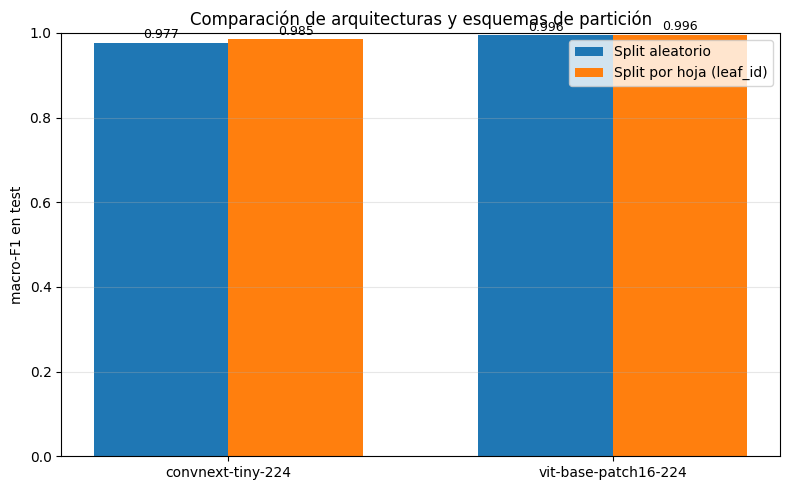

In [15]:
archs = df["Arquitectura"].unique()
x = np.arange(len(archs))
width = 0.35

f1_random = [df[(df.Arquitectura == a) & (df.Split == "random")]["Test macroF1"].values[0] for a in archs]
f1_leaf   = [df[(df.Arquitectura == a) & (df.Split == "leaf")]["Test macroF1"].values[0] for a in archs]

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, f1_random, width, label="Split aleatorio")
plt.bar(x + width/2, f1_leaf,   width, label="Split por hoja (leaf_id)")
plt.xticks(x, archs)
plt.ylabel("macro-F1 en test")
plt.title("Comparación de arquitecturas y esquemas de partición")
plt.ylim(0, 1.0)
for i, (a, b) in enumerate(zip(f1_random, f1_leaf)):
    plt.text(i - width/2, a + 0.01, f"{a:.3f}", ha="center", fontsize=9)
    plt.text(i + width/2, b + 0.01, f"{b:.3f}", ha="center", fontsize=9)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Curvas de entrenamiento y validación

Curvas de *loss* de train y validation para las cuatro corridas. En todos los casos ambas curvas descienden de forma conjunta y se estabilizan cerca de cero, sin que la *loss* de validación vuelva a subir ni se separe de la de entrenamiento. La ausencia de divergencia entre train y validation descarta el sobreajuste: el alto rendimiento no proviene de memorización del conjunto de entrenamiento.

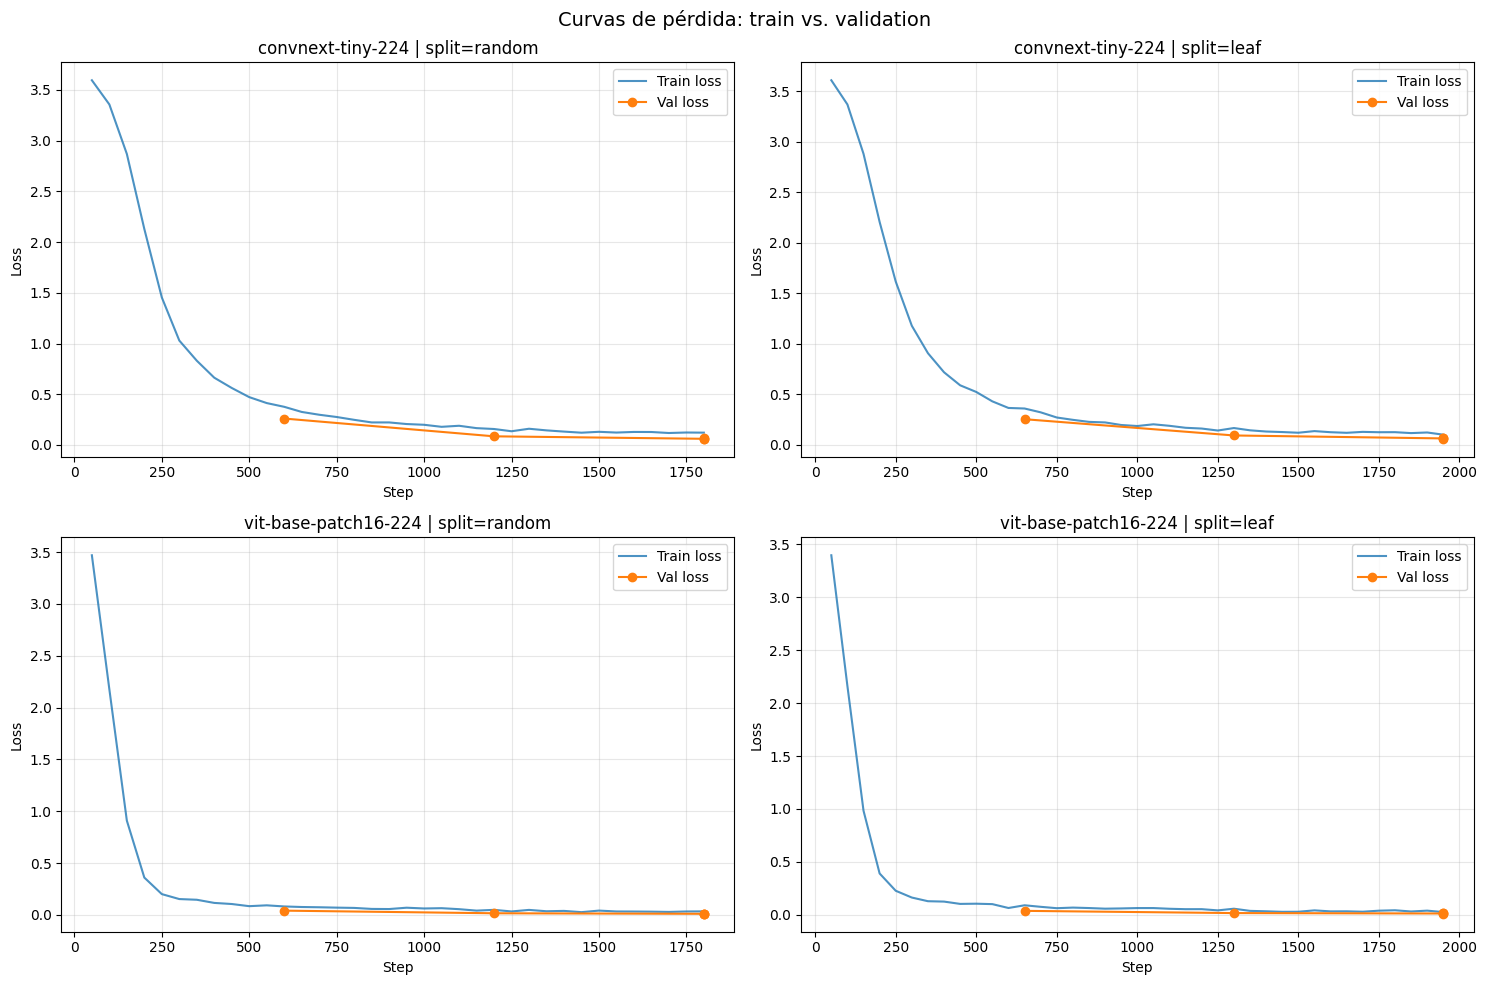

In [16]:
def extraer_curvas(log_history):
    steps, train_loss = [], []
    ep, val_loss, val_acc, val_f1 = [], [], [], []
    for reg in log_history:
        if "loss" in reg and "eval_loss" not in reg:
            steps.append(reg.get("step")); train_loss.append(reg.get("loss"))
        if "eval_loss" in reg:
            ep.append(reg.get("epoch")); val_loss.append(reg.get("eval_loss"))
            val_acc.append(reg.get("eval_accuracy")); val_f1.append(reg.get("eval_macro_f1"))
    return steps, train_loss, ep, val_loss, val_acc, val_f1

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()
for ax, r in zip(axes, resultados):
    steps, tl, ep, vl, va, vf = extraer_curvas(r["log_history"])
    ax.plot(steps, tl, label="Train loss", alpha=0.8)
    # Reescalamos epochs a 'steps' aprox para superponer (solo visual).
    if ep:
        step_per_epoch = (max(steps) / max(ep)) if steps and max(ep) else 1
        ax.plot([e * step_per_epoch for e in ep], vl, marker="o", label="Val loss")
    ax.set_title(f"{r['checkpoint'].split('/')[-1]} | split={r['split']}")
    ax.set_xlabel("Step"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle("Curvas de pérdida: train vs. validation", fontsize=14)
plt.tight_layout()
plt.show()

### Reporte de clasificación y matriz de confusión

Reporte por clase y matriz de confusión del modelo con mejor macro-F1 bajo el split por hoja. La gran mayoría de la masa se concentra en la diagonal; las confusiones residuales aparecen entre enfermedades con síntomas foliares visualmente similares.

Modelo elegido para análisis detallado: google/vit-base-patch16-224 (split=leaf)
test_acc=0.9969  test_macroF1=0.9957

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    1.0000    1.0000        94
                                 Apple___Black_rot     1.0000    1.0000    1.0000        93
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        41
                                   Apple___healthy     1.0000    1.0000    1.0000       247
                               Blueberry___healthy     1.0000    1.0000    1.0000       225
          Cherry_(including_sour)___Powdery_mildew     1.0000    1.0000    1.0000       158
                 Cherry_(including_sour)___healthy     1.0000    1.0000    1.0000       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9481    0.9481    0.9481        77
                       Corn_(maize)___Common_rust_  

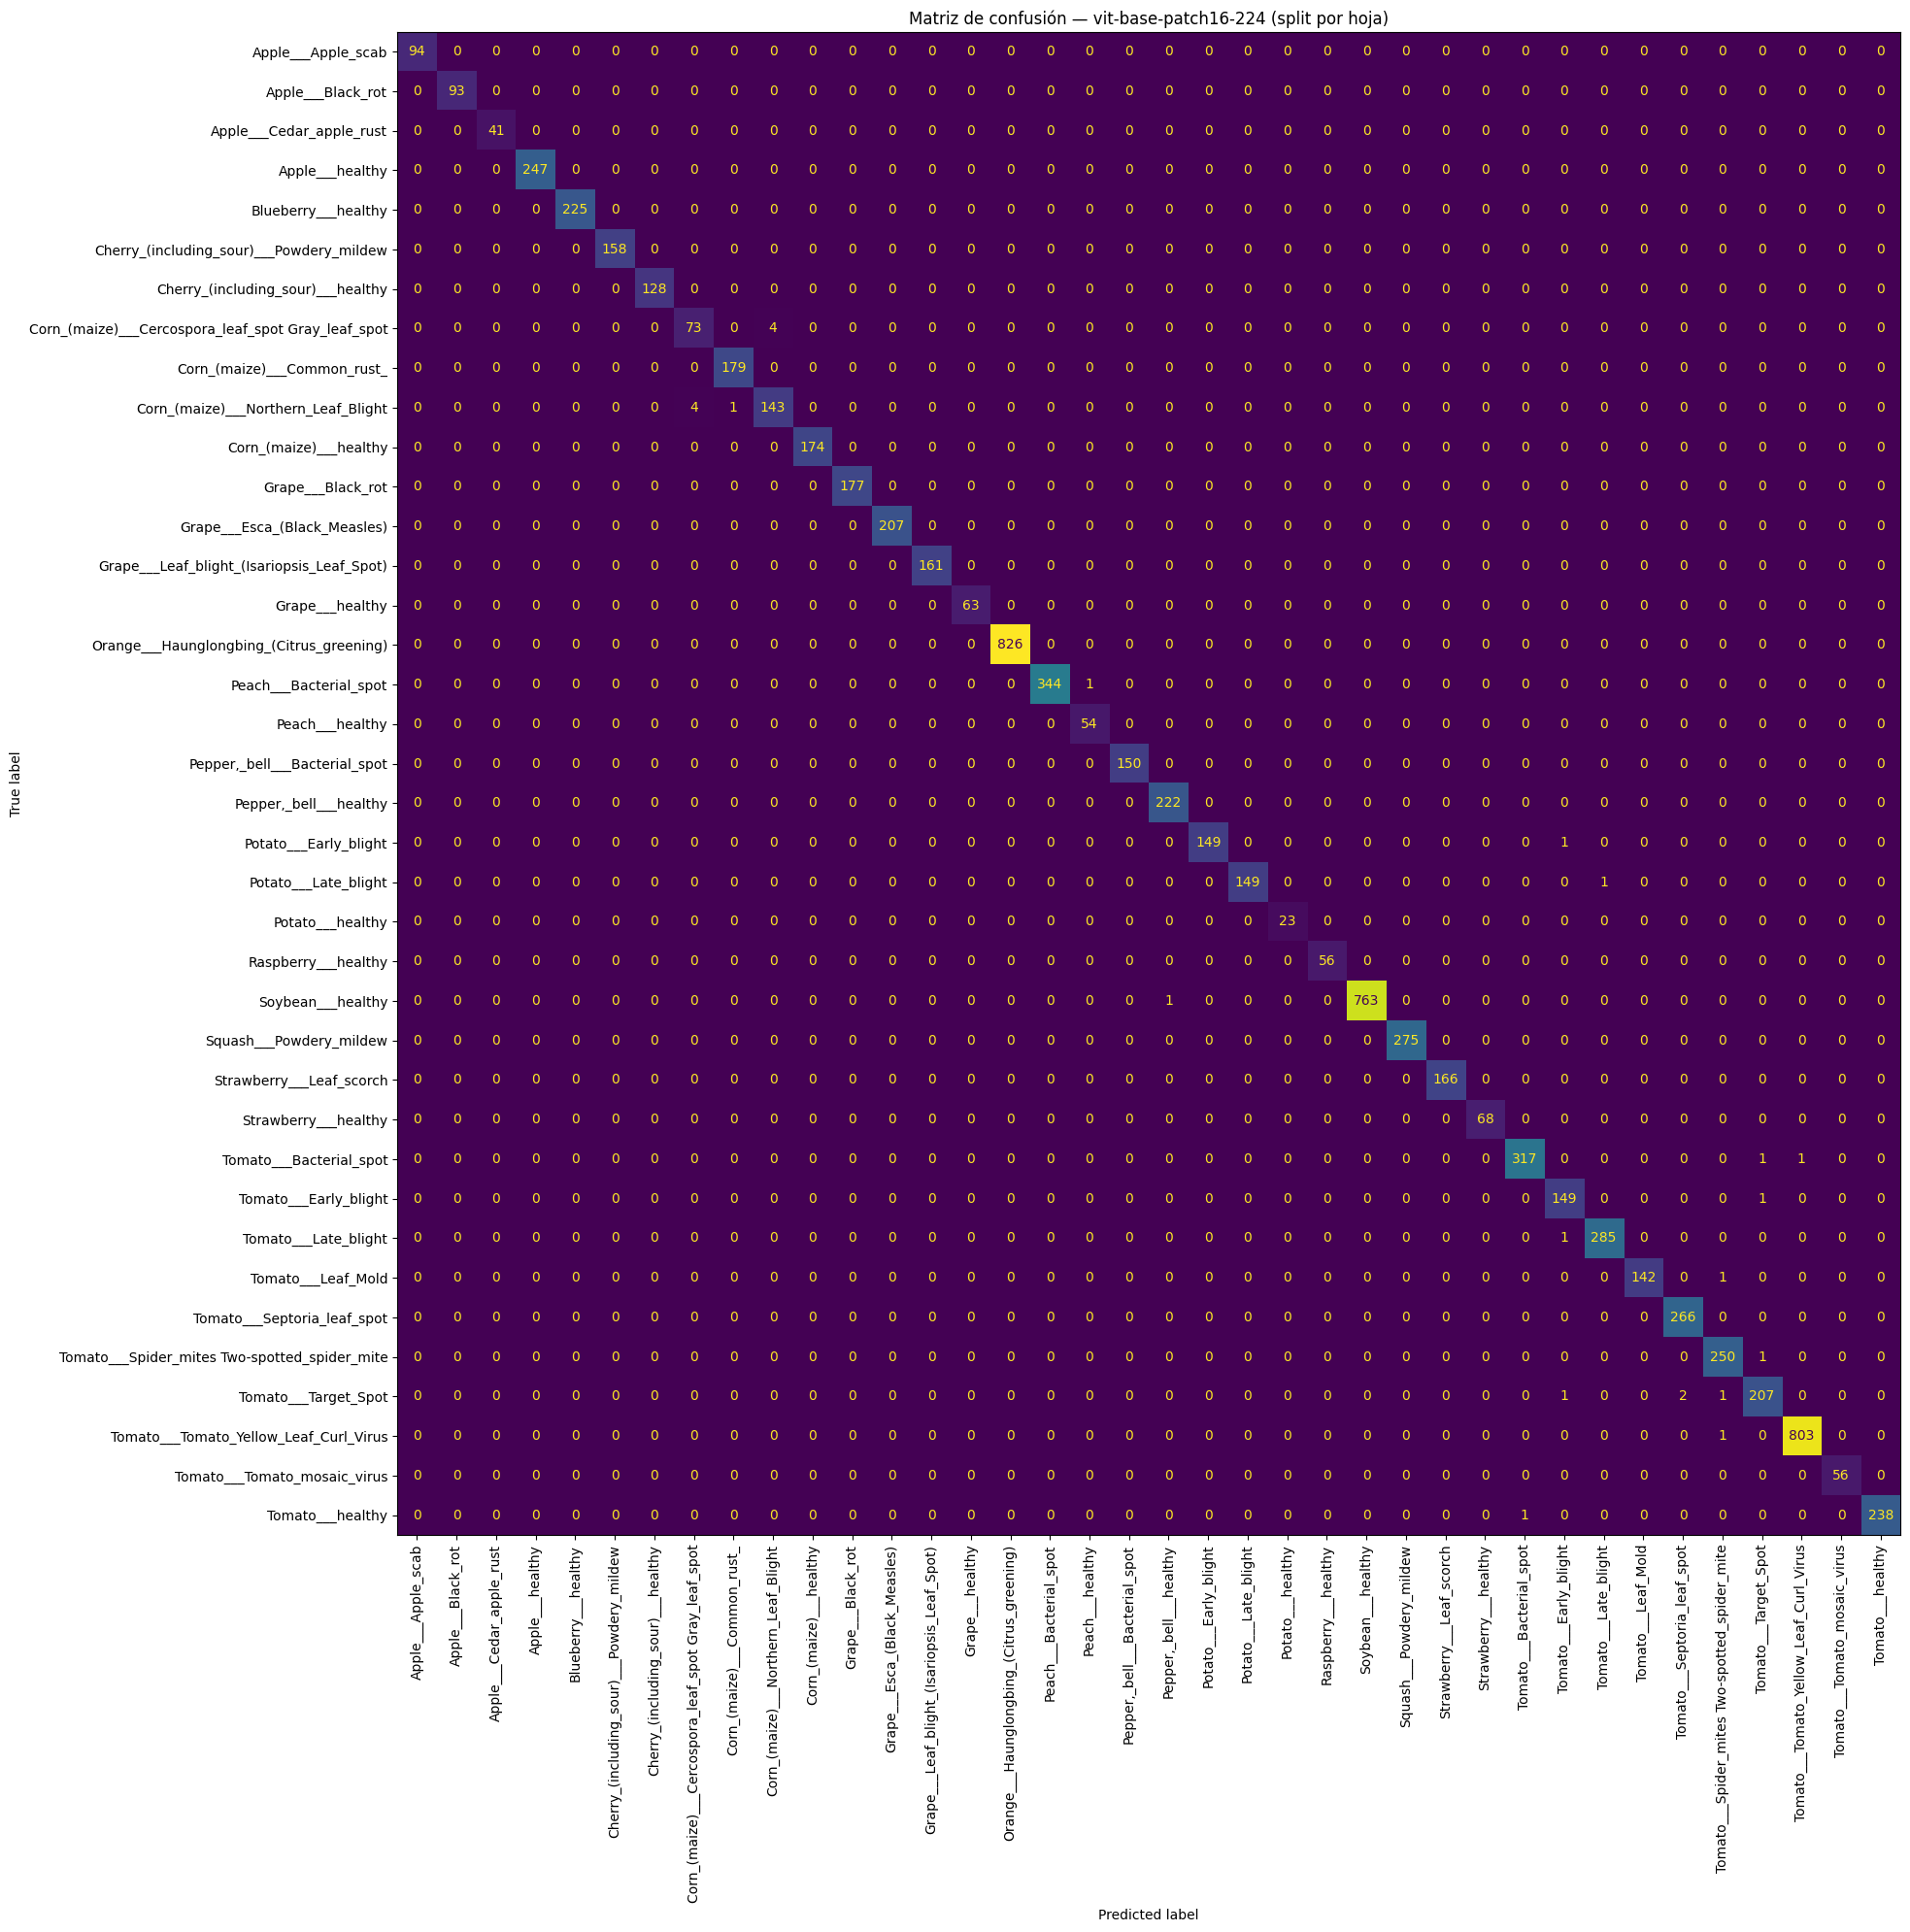

In [17]:
# Mejor experimento bajo split por hoja, por macro-F1 de test.
leaf_runs = [r for r in resultados if r["split"] == "leaf"]
mejor = max(leaf_runs, key=lambda r: r["test_macro_f1"]) if leaf_runs else max(resultados, key=lambda r: r["test_macro_f1"])
print(f"Modelo elegido para análisis detallado: {mejor['checkpoint']} (split={mejor['split']})")
print(f"test_acc={mejor['test_accuracy']:.4f}  test_macroF1={mejor['test_macro_f1']:.4f}\n")

print(classification_report(
    mejor["y_true"], mejor["y_pred"],
    target_names=labels_ordenadas, digits=4, zero_division=0,
))

cm = confusion_matrix(mejor["y_true"], mejor["y_pred"])
fig, ax = plt.subplots(figsize=(20, 20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_ordenadas)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title(f"Matriz de confusión — {mejor['checkpoint'].split('/')[-1]} (split por hoja)")
plt.tight_layout()
plt.show()

### Clases más difíciles y ejemplos de error

Clases con menor F1 y muestra de imágenes mal clasificadas. Los errores se concentran en pares de enfermedades de apariencia parecida (por ejemplo, distintas afecciones del tomate y del maíz), donde las lesiones foliares son difíciles de distinguir incluso visualmente.

In [18]:
from sklearn.metrics import f1_score

# F1 por clase para el modelo elegido.
f1_por_clase = f1_score(mejor["y_true"], mejor["y_pred"], average=None, labels=range(NUM_CLASSES), zero_division=0)
orden = np.argsort(f1_por_clase)
print("Clases más difíciles (menor F1):")
for idx in orden[:8]:
    print(f"  {labels_ordenadas[idx]:55s}  F1={f1_por_clase[idx]:.3f}")

Clases más difíciles (menor F1):
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       F1=0.948
  Corn_(maize)___Northern_Leaf_Blight                      F1=0.969
  Tomato___Target_Spot                                     F1=0.983
  Tomato___Early_blight                                    F1=0.987
  Peach___healthy                                          F1=0.991
  Tomato___Spider_mites Two-spotted_spider_mite            F1=0.992
  Tomato___Bacterial_spot                                  F1=0.995
  Tomato___Septoria_leaf_spot                              F1=0.996


Total de errores en test: 25 de 8146


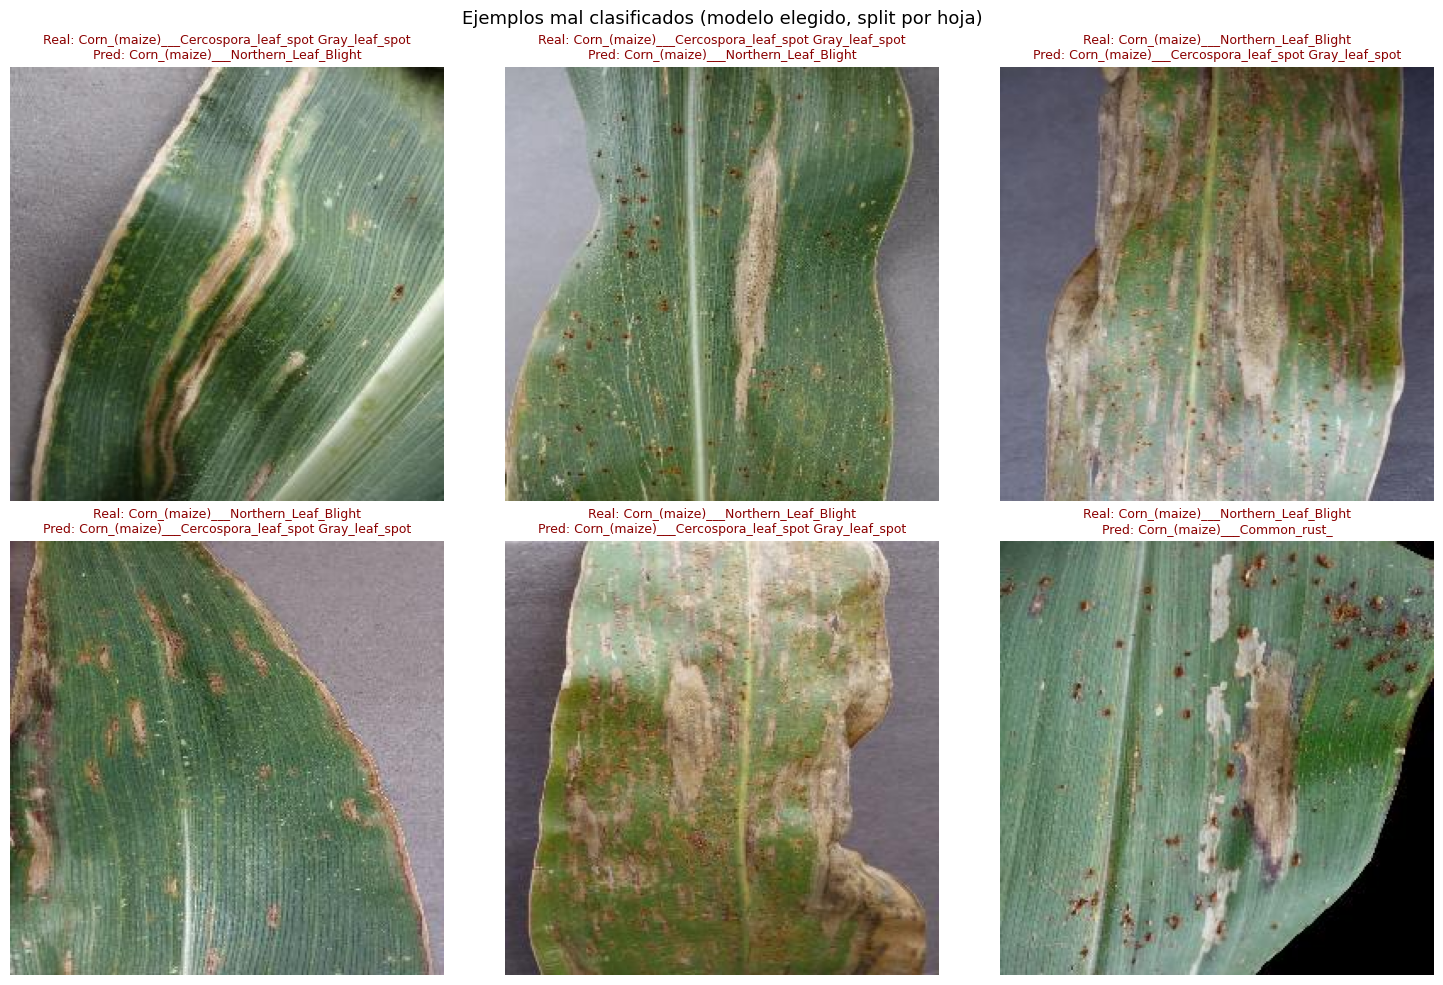

In [19]:
# Visualización de algunos errores. Reconstruimos el test del split por hoja para
# poder mostrar las imágenes (sin transforms) correspondientes a los índices de error.
dd_leaf = make_leaf_split()
test_imgs = dd_leaf["test"]

errores = np.where(mejor["y_true"] != mejor["y_pred"])[0]
print(f"Total de errores en test: {len(errores)} de {len(mejor['y_true'])}")

n_show = min(6, len(errores))
if n_show > 0:
    sel = errores[:n_show]
    cols = 3
    rows = (n_show + cols - 1) // cols
    plt.figure(figsize=(15, 5 * rows))
    for k, idx in enumerate(sel):
        plt.subplot(rows, cols, k + 1)
        plt.imshow(test_imgs[int(idx)]["image"])
        real = id2label[int(mejor["y_true"][idx])]
        pred = id2label[int(mejor["y_pred"][idx])]
        plt.title(f"Real: {real}\nPred: {pred}", fontsize=9, color="darkred")
        plt.axis("off")
    plt.suptitle("Ejemplos mal clasificados (modelo elegido, split por hoja)", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("No hubo errores que mostrar.")

### Predicción sobre una imagen individual

Verificación cualitativa: se toma una imagen del conjunto de test y se compara su etiqueta real con la predicha por el modelo seleccionado.

Etiqueta real: Cherry_(including_sour)___healthy
Etiqueta predicha: Cherry_(including_sour)___healthy


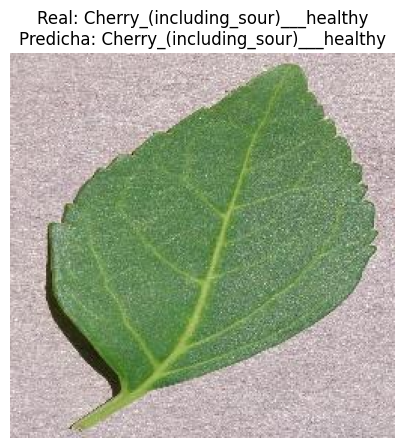

In [20]:
indice = 1000
img_proc = mejor["image_processor"]
_, eval_tf_best, _ = build_transforms(img_proc)

imagen = test_imgs[indice]["image"]
label_real = test_imgs[indice]["label"]

modelo_best = mejor["trainer"].model
tensor = eval_tf_best(imagen.convert("RGB")).unsqueeze(0).to(modelo_best.device)
with torch.no_grad():
    logits = modelo_best(pixel_values=tensor).logits
    pred_id = logits.argmax(dim=1).item()

print("Etiqueta real:", label_real)
print("Etiqueta predicha:", id2label[pred_id])

plt.figure(figsize=(5, 5))
plt.imshow(imagen)
plt.title(f"Real: {label_real}\nPredicha: {id2label[pred_id]}")
plt.axis("off")
plt.show()

## Evaluación de resultados y discusión

### Comparación de arquitecturas

Ambas arquitecturas alcanzan un rendimiento muy alto en test, reproduciendo los resultados reportados en la literatura para PlantVillage y confirmando que el pipeline de fine-tuning es correcto (línea base). ViT Base supera de forma consistente a ConvNeXt Tiny: macro-F1 de 0.9958 frente a 0.9905 y un *loss* de test de 0.0094 frente a 0.0277. La ventaja de ViT, aunque pequeña en valor absoluto, es estable en ambos esquemas de partición.

### Sobre el alto rendimiento y la ausencia de sobreajuste

El macro-F1 cercano al 99 % no corresponde a sobreajuste. El sobreajuste se manifiesta como una brecha entre el rendimiento en entrenamiento y en prueba, acompañada de una *loss* de validación que crece mientras la de entrenamiento desciende. Las curvas de las cuatro corridas no presentan esa divergencia: train y validation convergen juntas cerca de cero y se mantienen estables.

Tampoco se debe a fuga de información por hoja. El split oficial de PlantVillage ya está agrupado a nivel de hoja física, y el split por `leaf_id` construido en este trabajo reproduce el mismo rendimiento (diferencia de macro-F1 inferior a 0.004). Si existiera fuga, el split por hoja habría producido una caída apreciable, lo que no ocurre.

El rendimiento se explica por la naturaleza del dataset: PlantVillage está compuesto por imágenes de laboratorio con fondo uniforme, una sola hoja centrada e iluminación controlada. En esas condiciones la tarea es separable con alta precisión por arquitecturas preentrenadas modernas. Es una limitación conocida del benchmark: las métricas elevadas no garantizan la misma generalización sobre fotografías de campo.

### Análisis por clase

Las confusiones se concentran en clases con síntomas visualmente parecidos, por ejemplo entre enfermedades del maíz (*Cercospora / Gray leaf spot* y *Northern Leaf Blight*) y entre afecciones del tomate (*Early blight*, *Target Spot*, *Septoria*), donde las lesiones foliares son difíciles de diferenciar.

### Mejoras posibles

Para acercar la evaluación a un escenario real conviene incorporar datos de campo (por ejemplo PlantDoc) en validación, aumentos de datos más agresivos sobre fondo e iluminación, y un mecanismo de rechazo para entradas fuera de distribución en la demo.

### Conclusión

ViT Base y ConvNeXt Tiny resuelven PlantVillage con macro-F1 superior al 99 %, con ligera ventaja de ViT. El rendimiento no se debe a sobreajuste ni a fuga de información, ambos descartados experimentalmente, sino a la facilidad intrínseca del dataset de laboratorio, lo que delimita el alcance de los resultados frente a condiciones de campo.